# MMIP Week 03：CNN 影像分類完整作業

**資料集：CIFAR-10｜模型：Plain CNN、MobileNetV2｜框架：TensorFlow/Keras**

本 Notebook 完整涵蓋 Quiz 1–3 的基礎與進階要求：資料說明與切分、Top-1/Top-5、Testing Dataset 預測、逐類 ROC 與 Macro-AUC、參數量比較、兩種模型的超參數實驗、Data Augmentation 對照、兩個 Kernel 視覺化，以及 Grad-CAM 可解釋性分析。

> 建議在 Google Colab 選擇「執行階段 → 變更執行階段類型 → T4 GPU」。正式繳交前設定 `FULL_RUN=True` 並「全部執行」，保留所有輸出。

In [13]:
# 0. 環境與可重現性設定
import os, random, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             auc, roc_auc_score, accuracy_score)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# False：先確認流程可跑；True：正式實驗與繳交模式
FULL_RUN = True
EPOCHS = 30 if FULL_RUN else 3
HP_EPOCHS = 12 if FULL_RUN else 2
BATCH_SIZE = 128
IMG_SIZE = 96
AUTOTUNE = tf.data.AUTOTUNE
OUT = Path('cnn_homework_outputs'); OUT.mkdir(exist_ok=True)
print('TensorFlow:', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Quiz 1：準備資料集（基礎 15 分）

### 1.1 資料來源與內容

CIFAR-10 由 Alex Krizhevsky、Vinod Nair 與 Geoffrey Hinton 整理，透過 `tf.keras.datasets.cifar10` 取得。資料共 **60,000 張 32×32 RGB 彩色影像**，均衡分成 10 類，每類 6,000 張；原始官方切分為訓練 50,000 張、測試 10,000 張。

### 1.2 問題定義與分類任務

本作業要解決的是**單標籤、多類別影像分類問題**：給定一張 32×32 RGB 圖片，模型必須判斷圖片中的主要物體最接近哪一種真實事物。可選類別共有 10 種：飛機（airplane）、汽車（automobile）、鳥（bird）、貓（cat）、鹿（deer）、狗（dog）、青蛙（frog）、馬（horse）、船（ship）與卡車（truck）。例如輸入一張船的圖片，期望模型在 10 個類別中將 `ship` 判為最可能的類別。

模型輸入張量的形狀為 32×32×3，輸出則為 10 維 softmax 機率分布；機率最高者作為最終預測。訓練使用 sparse categorical cross-entropy。Top-1 Accuracy 表示最高機率類別是否等於真實標籤；Top-5 Accuracy 則表示真實標籤是否位於模型預測機率最高的五個類別內。

### 1.3 切分策略

保留官方 10,000 張測試集，只用於最終評估。原始 50,000 張訓練資料以固定亂數種子 42，逐類抽取 500 張作為驗證資料，形成 **45,000 張訓練集、5,000 張驗證集與 10,000 張測試集**。因此每個類別在驗證集中均有 500 張，能維持類別平衡並避免測試集資訊洩漏。大型影像模型的重複訓練成本較高，因此本作業採固定 hold-out validation，而不使用 K-fold cross-validation。


,split,samples
0,train,45000
1,validation,5000
2,test,10000


image shape: (32, 32, 3)


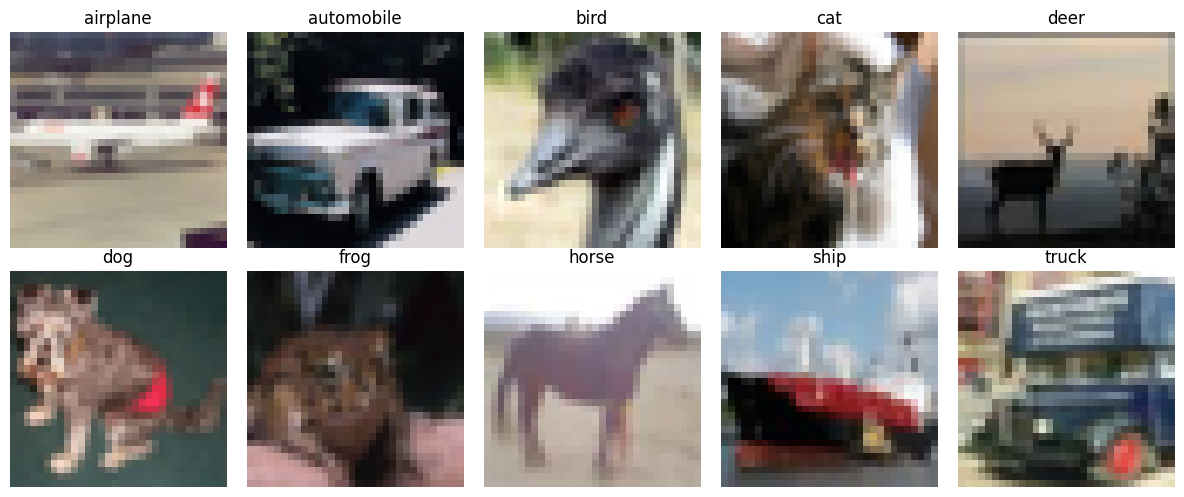

In [14]:
# 1. 載入、切分並檢查資料
(x_all, y_all), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_all, y_test = y_all.squeeze(), y_test.squeeze()
class_names = np.array(['airplane','automobile','bird','cat','deer',
                        'dog','frog','horse','ship','truck'])

rng = np.random.default_rng(SEED)
train_idx, val_idx = [], []
for c in range(10):
    idx = np.where(y_all == c)[0]
    rng.shuffle(idx)
    val_idx.extend(idx[:500]); train_idx.extend(idx[500:])
rng.shuffle(train_idx); rng.shuffle(val_idx)
x_train, y_train = x_all[train_idx], y_all[train_idx]
x_val, y_val = x_all[val_idx], y_all[val_idx]

split_table = pd.DataFrame({
    'split':['train','validation','test'],
    'samples':[len(x_train),len(x_val),len(x_test)]
})
display(split_table)
print('image shape:', x_train.shape[1:])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c, ax in enumerate(axes.flat):
    i = np.where(y_train == c)[0][0]
    ax.imshow(x_train[i]); ax.set_title(class_names[c]); ax.axis('off')
plt.tight_layout(); plt.savefig(OUT/'dataset_examples.png', dpi=180); plt.show()

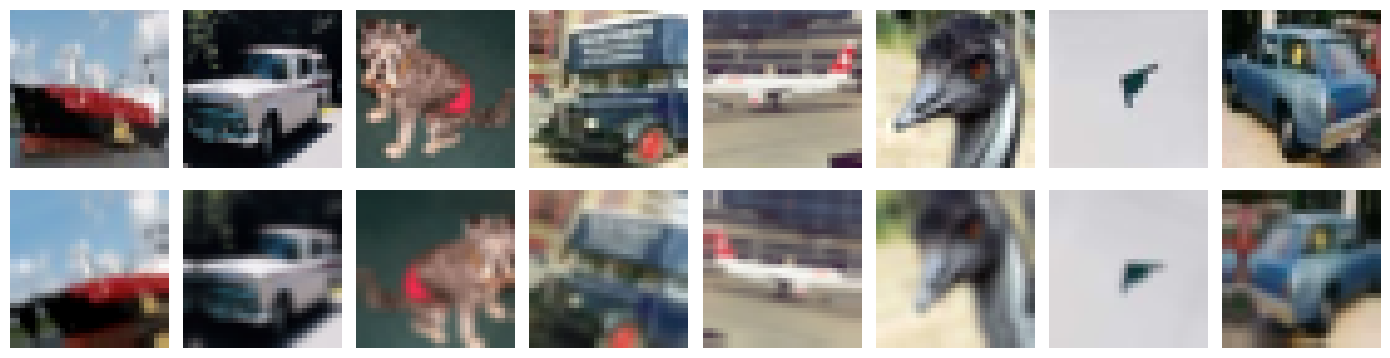

In [15]:
# 2. tf.data pipeline 與 Data Augmentation
def make_ds(x, y, training=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training: ds = ds.shuffle(min(len(x), 10000), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_ds(x_train, y_train, True)
val_ds = make_ds(x_val, y_val)
test_ds = make_ds(x_test, y_test)

# CIFAR-10 類別不因水平翻轉改變；小幅位移/旋轉/縮放模擬拍攝差異。
# 不使用垂直翻轉，因車、船、動物倒置並不符合常見自然影像分布。
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

sample = tf.cast(x_train[:8], tf.float32)
aug = augmentation(sample, training=True).numpy().clip(0,255).astype('uint8')
fig, axes = plt.subplots(2, 8, figsize=(14,4))
for i in range(8):
    axes[0,i].imshow(x_train[i]); axes[1,i].imshow(aug[i])
    axes[0,i].axis('off'); axes[1,i].axis('off')
axes[0,0].set_ylabel('Original'); axes[1,0].set_ylabel('Augmented')
plt.tight_layout(); plt.savefig(OUT/'augmentation_examples.png', dpi=180); plt.show()

## Quiz 2：訓練 CNN 影像分類模型

### 自行設計的 Plain CNN：MultiScale-Pyramid CNN

本作業的 Plain CNN 並非套用現成架構，而是依 CIFAR-10 的 32×32 小影像自行設計 **MultiScale-Pyramid CNN**：

| 階段 | 設計 | 思考理由 |
|---|---|---|
| 多尺度輸入層 | 平行 3×3 與 5×5 convolution，再串接 | 3×3 偏向局部邊緣，5×5 同時觀察較大範圍；小圖中物件尺度差異仍明顯 |
| Stage 1 | 特徵融合卷積 + MaxPooling | 融合兩分支並將 32×32 降為 16×16 |
| Stage 2–3 | 通道數逐層增加 32→64→128，空間逐層縮小 | 解析度降低時增加通道容量，以表達更抽象的形狀與部件 |
| Batch Normalization | 每個卷積後正規化 | 穩定梯度及加速收斂 |
| Dropout | 每個 stage 後加入 | 抑制共適應，降低過擬合 |
| Global Average Pooling | 取代大型 Flatten + Dense | 大幅減少參數，讓每個通道彙整全域證據 |

整個模型只使用標準 convolution、activation、pooling、normalization、dropout 與 dense，**不使用預訓練權重、殘差模組或任何現成 backbone**。對照的經典 CNN 則使用 ImageNet 預訓練 MobileNetV2，先凍結 backbone 訓練分類頭，再解凍最後 30 層以較小學習率微調。

In [16]:
# 3. 模型工廠、訓練與評估工具
def build_plain(augment=False, lr=1e-3, dropout=0.3, filters=(32,64,128)):
    inp = keras.Input((32,32,3), name='image')
    x = inp
    if augment: x = augmentation(x)
    x = layers.Rescaling(1./255)(x)

    # 自行設計的多尺度 stem：3×3 擷取局部細節，5×5 擷取較大範圍形狀。
    # 兩分支各使用一半通道，concat 後總寬度仍等於 filters[0]，控制參數量。
    branch3 = layers.Conv2D(filters[0]//2, 3, padding='same', use_bias=False,
                            name='multiscale_3x3')(x)
    branch5 = layers.Conv2D(filters[0]//2, 5, padding='same', use_bias=False,
                            name='multiscale_5x5')(x)
    x = layers.Concatenate(name='multiscale_concat')([branch3, branch5])
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.Activation('relu', name='stem_relu')(x)

    # 金字塔式特徵抽取：空間尺寸下降，通道容量上升。
    for i, f in enumerate(filters, start=1):
        x = layers.Conv2D(f, 3, padding='same', use_bias=False, name=f'conv{i}_a')(x)
        x = layers.BatchNormalization(name=f'bn{i}_a')(x)
        x = layers.Activation('relu', name=f'relu{i}_a')(x)
        x = layers.Conv2D(f, 3, padding='same', use_bias=False, name=f'conv{i}_b')(x)
        x = layers.BatchNormalization(name=f'bn{i}_b')(x)
        x = layers.Activation('relu', name=f'relu{i}_b')(x)
        x = layers.MaxPooling2D(name=f'pool{i}')(x)
        x = layers.Dropout(dropout, name=f'dropout{i}')(x)
    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(10, activation='softmax', name='prediction')(x)
    model = keras.Model(inp, out, name='StudentMultiScaleCNN_Aug' if augment else 'StudentMultiScaleCNN')
    model.compile(keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=[keras.metrics.SparseCategoricalAccuracy(name='top1'),
                           keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5')])
    return model

def build_mobilenet(augment=False, lr=1e-3, dropout=0.3):
    inp = keras.Input((32,32,3), name='image')
    x = inp
    if augment: x = augmentation(x)
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(x)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                                             include_top=False, weights='imagenet')
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x); x = layers.Dropout(dropout)(x)
    out = layers.Dense(10, activation='softmax', name='prediction')(x)
    model = keras.Model(inp, out, name='MobileNetV2_Aug' if augment else 'MobileNetV2')
    model.backbone = base
    model.compile(keras.optimizers.Adam(lr), loss='sparse_categorical_crossentropy',
                  metrics=[keras.metrics.SparseCategoricalAccuracy(name='top1'),
                           keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5')])
    return model

def callbacks(tag):
    return [keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_top1', mode='max'),
            keras.callbacks.ReduceLROnPlateau(patience=2, factor=.3),
            keras.callbacks.ModelCheckpoint(str(OUT/f'{tag}.keras'), save_best_only=True, monitor='val_top1', mode='max')]

def train_model(model, tag, epochs=EPOCHS):
    start=time.time()
    hist=model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks(tag), verbose=2)
    return hist, time.time()-start

def plot_history(histories, filename):
    fig, axes=plt.subplots(1,2,figsize=(12,4))
    for label,h in histories.items():
        axes[0].plot(h.history['val_top1'],label=label)
        axes[1].plot(h.history['val_loss'],label=label)
    axes[0].set_title('Validation Top-1'); axes[1].set_title('Validation Loss')
    for ax in axes: ax.set_xlabel('epoch'); ax.grid(alpha=.3); ax.legend()
    plt.tight_layout(); plt.savefig(OUT/filename,dpi=180); plt.show()

Model: "StudentMultiScaleCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 32, 32, 3) │          0 │ image[0][0]       │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiscale_3x3      │ (None, 32, 32,    │        432 │ rescaling_1[0][0] │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiscale_5x5      │ (None, 32, 32,    │      1,200 │ rescaling_1[0][0] │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiscale_concat   │ (None, 32, 32,    │          0 │ multiscale_3x3[0… │
│ (Concatenate)       │ 32)               │            │ multiscale_5x5[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        128 │ multiscale_conca… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_a (Conv2D)    │ (None, 32, 32,    │      9,216 │ stem_relu[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1_a               │ (None, 32, 32,    │        128 │ conv1_a[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1_a             │ (None, 32, 32,    │          0 │ bn1_a[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_b (Conv2D)    │ (None, 32, 32,    │      9,216 │ relu1_a[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1_b               │ (None, 32, 32,    │        128 │ conv1_b[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1_b             │ (None, 32, 32,    │          0 │ bn1_b[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 16, 16,    │          0 │ relu1_b[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 16, 16,    │          0 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a (Conv2D)    │ (None, 16, 16,    │     18,432 │ dropout1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2_a               │ (None, 16, 16,    │        256 │ conv2_a[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                 

 Total params: 299,754 (1.14 MB)

 Trainable params: 298,794 (1.14 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
352/352 - 23s - 66ms/step - loss: 1.3786 - top1: 0.4977 - top5: 0.9259 - val_loss: 2.0443 - val_top1: 0.3382 - val_top5: 0.8132 - learning_rate: 0.0010
Epoch 2/30
352/352 - 7s - 20ms/step - loss: 1.0148 - top1: 0.6396 - top5: 0.9667 - val_loss: 1.2880 - val_top1: 0.5556 - val_top5: 0.9454 - learning_rate: 0.0010
Epoch 3/30
352/352 - 7s - 21ms/step - loss: 0.8878 - top1: 0.6856 - top5: 0.9742 - val_loss: 1.0041 - val_top1: 0.6506 - val_top5: 0.9660 - learning_rate: 0.0010
Epoch 4/30
352/352 - 7s - 20ms/step - loss: 0.8029 - top1: 0.7186 - top5: 0.9790 - val_loss: 0.9420 - val_top1: 0.6790 - val_top5: 0.9646 - learning_rate: 0.0010
Epoch 5/30
352/352 - 7s - 20ms/step - loss: 0.7261 - top1: 0.7436 - top5: 0.9845 - val_loss: 0.8191 - val_top1: 0.7118 - val_top5: 0.9796 - learning_rate: 0.0010
Epoch 6/30
352/352 - 7s - 19ms/step - loss: 0.6795 - top1: 0.7608 - top5: 0.9861 - val_loss: 0.8073 - val_top1: 0.7204 - val_top5: 0.9766 - learning_rate: 0.0010
Epoch 7/30
352/352 - 7s - 1

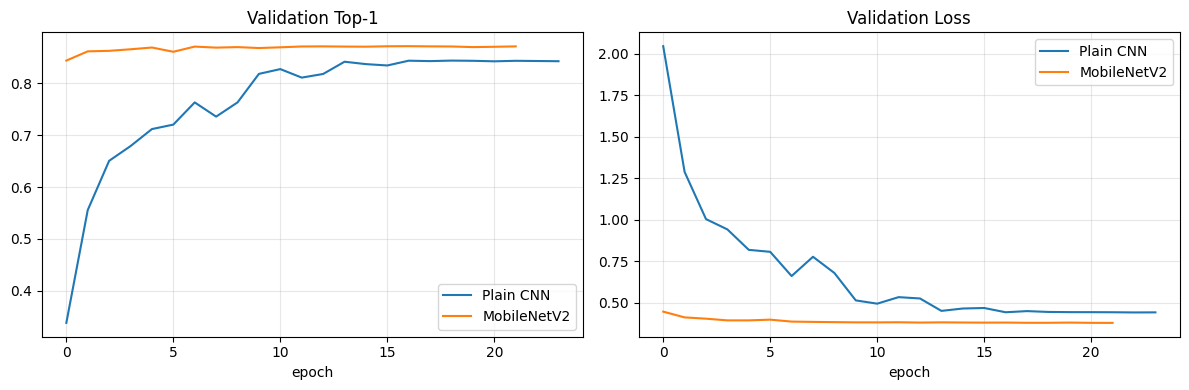

In [17]:
# 4. Plain CNN 與經典 Backbone 基準模型
plain = build_plain(augment=False)
plain.summary()
plain_hist, plain_time = train_model(plain, 'plain_baseline')

mobile = build_mobilenet(augment=False)
mobile_hist, mobile_time = train_model(mobile, 'mobile_baseline')

# 正式模式：解凍最後 30 層，用低 learning rate fine-tune
if FULL_RUN:
    mobile.backbone.trainable = True
    for layer in mobile.backbone.layers[:-30]: layer.trainable = False
    mobile.compile(keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy',
                   metrics=[keras.metrics.SparseCategoricalAccuracy(name='top1'),
                            keras.metrics.SparseTopKCategoricalAccuracy(k=5,name='top5')])
    ft_hist = mobile.fit(train_ds, validation_data=val_ds, epochs=10,
                         callbacks=callbacks('mobile_finetuned'), verbose=2)

plot_history({'Plain CNN':plain_hist, 'MobileNetV2':mobile_hist}, 'baseline_history.png')

,model,top1,top5,parameters,train_seconds
0,Plain CNN,0.8427,0.9931,"299,754",179.8
1,MobileNetV2,0.8909,0.9965,"2,270,794",195.0


,index,true,plain_pred,plain_conf,mobile_pred,mobile_conf
0,0,cat,cat,0.985446,cat,0.966122
1,1,ship,ship,0.997034,ship,0.999999
2,2,ship,ship,0.925781,ship,0.828305
3,3,airplane,ship,0.697515,airplane,0.984154
4,4,frog,frog,0.997607,frog,0.999784
5,5,frog,frog,0.992519,frog,0.999494
6,6,automobile,automobile,0.771611,automobile,0.999975
7,7,frog,frog,0.877463,frog,0.996811
8,8,cat,cat,0.780713,cat,0.986562
9,9,automobile,automobile,0.788903,automobile,0.999892


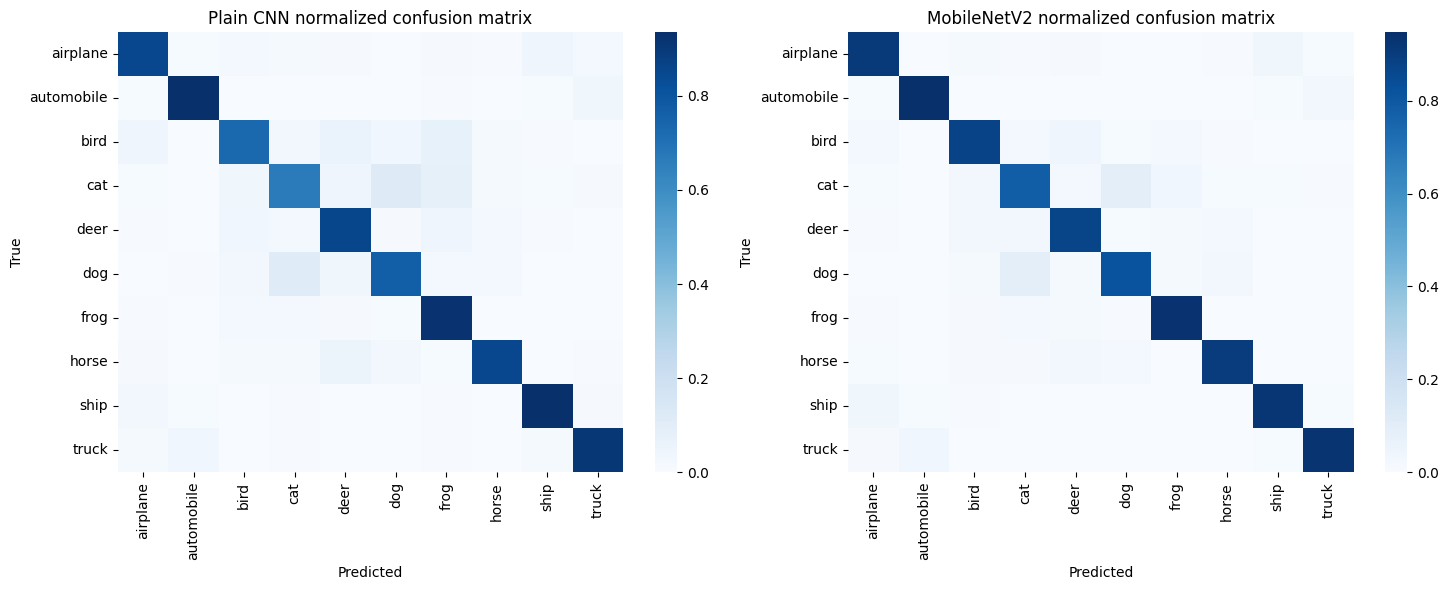

In [18]:
# 5. Testing Dataset：Top-1/Top-5、預測結果與混淆矩陣
def evaluate_model(model, name, train_seconds=np.nan):
    metrics = model.evaluate(test_ds, return_dict=True, verbose=0)
    probs = model.predict(test_ds, verbose=0)
    pred = probs.argmax(1)
    result = {'model':name, 'top1':metrics['top1'], 'top5':metrics['top5'],
              'parameters':model.count_params(), 'train_seconds':train_seconds}
    return result, probs, pred

rows=[]; predictions={}; probabilities={}
for model,name,secs in [(plain,'Plain CNN',plain_time),(mobile,'MobileNetV2',mobile_time)]:
    row,probs,pred=evaluate_model(model,name,secs)
    rows.append(row); predictions[name]=pred; probabilities[name]=probs
comparison=pd.DataFrame(rows)
display(comparison.style.format({'top1':'{:.4f}','top5':'{:.4f}','parameters':'{:,}','train_seconds':'{:.1f}'}))
comparison.to_csv(OUT/'model_comparison.csv',index=False)

pred_table=pd.DataFrame({'index':np.arange(len(y_test)), 'true':class_names[y_test],
                         'plain_pred':class_names[predictions['Plain CNN']],
                         'plain_conf':probabilities['Plain CNN'].max(1),
                         'mobile_pred':class_names[predictions['MobileNetV2']],
                         'mobile_conf':probabilities['MobileNetV2'].max(1)})
display(pred_table.head(20)); pred_table.to_csv(OUT/'test_predictions.csv',index=False)

fig,axes=plt.subplots(1,2,figsize=(15,6))
for ax,name in zip(axes,predictions):
    cm=confusion_matrix(y_test,predictions[name],normalize='true')
    sns.heatmap(cm,xticklabels=class_names,yticklabels=class_names,cmap='Blues',ax=ax)
    ax.set_title(name+' normalized confusion matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig(OUT/'confusion_matrices.png',dpi=180); plt.show()

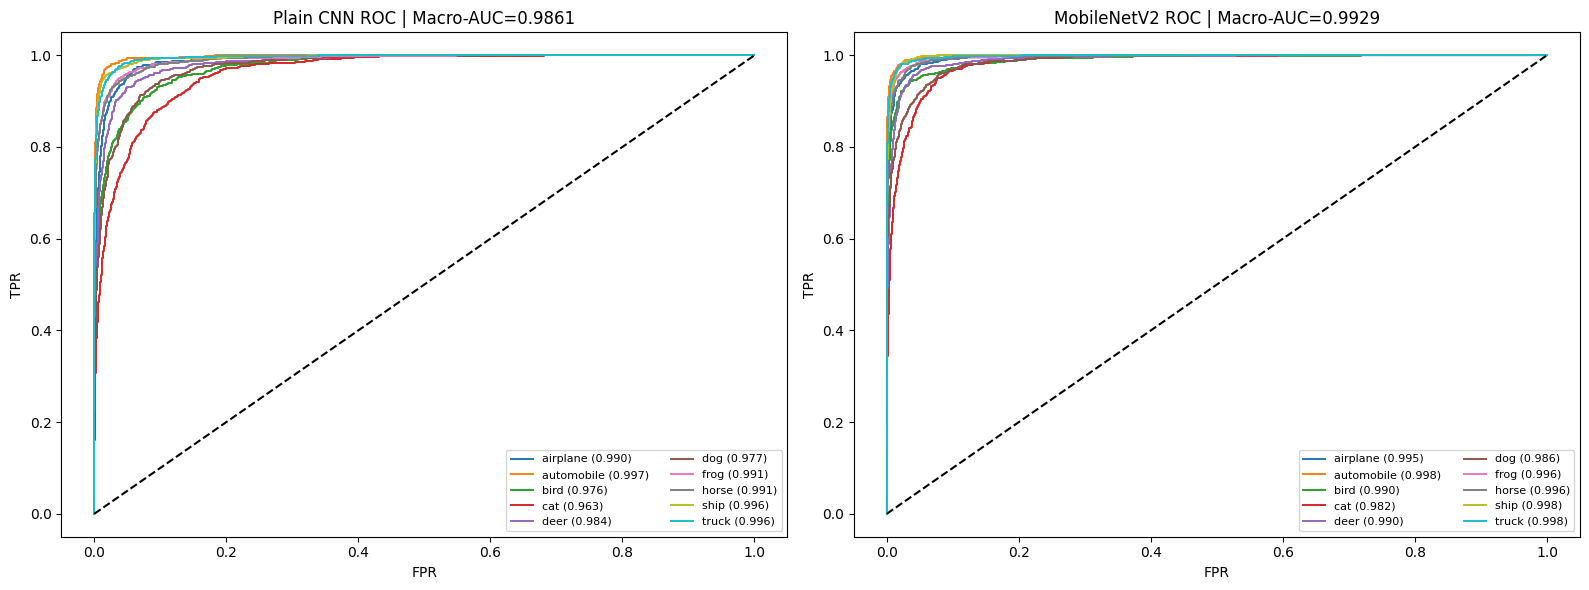

,model,macro_auc,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
0,Plain CNN,0.986053,0.989900,0.997357,0.975858,0.963123,0.983968,0.976629,0.991142,0.991159,0.995601,0.995788
1,MobileNetV2,0.992878,0.994798,0.998442,0.989512,0.982002,0.990415,0.986477,0.996078,0.995571,0.997827,0.997654


In [19]:
# 6. 各類別 ROC Curve 與 Macro-AUC（One-vs-Rest）
y_bin=label_binarize(y_test,classes=np.arange(10))
auc_rows=[]
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,(name,probs) in zip(axes,probabilities.items()):
    class_aucs=[]
    for c in range(10):
        fpr,tpr,_=roc_curve(y_bin[:,c],probs[:,c]); score=auc(fpr,tpr)
        class_aucs.append(score); ax.plot(fpr,tpr,lw=1.4,label=f'{class_names[c]} ({score:.3f})')
    macro=roc_auc_score(y_bin,probs,average='macro',multi_class='ovr')
    auc_rows.append({'model':name,'macro_auc':macro,**{class_names[c]:class_aucs[c] for c in range(10)}})
    ax.plot([0,1],[0,1],'k--'); ax.set(title=f'{name} ROC | Macro-AUC={macro:.4f}',xlabel='FPR',ylabel='TPR')
    ax.legend(fontsize=8,ncol=2)
plt.tight_layout(); plt.savefig(OUT/'roc_curves.png',dpi=180); plt.show()
auc_table=pd.DataFrame(auc_rows); display(auc_table); auc_table.to_csv(OUT/'auc_scores.csv',index=False)

### 基準模型結果分析

測試集結果顯示，Plain CNN 的 Top-1／Top-5 Accuracy 為 **0.8427／0.9931**，MobileNetV2 為 **0.8909／0.9965**；Macro-AUC 分別為 **0.986053** 與 **0.992878**。MobileNetV2 的 Top-1 比 Plain CNN 高 0.0482（4.82 個百分點），顯示 ImageNet 預訓練特徵及後續 fine-tuning 能有效提升 CIFAR-10 的辨識能力。

代價方面，Plain CNN 有 **299,754** 個參數，MobileNetV2 有 **2,270,794** 個參數，約為前者的 7.58 倍。MobileNetV2 表格中的 195.0 秒只記錄初始分類頭訓練，不包含後續 10 epochs fine-tuning，因此不宜直接把該欄視為完整端到端訓練時間。

Accuracy 只反映最後選出的離散類別是否正確；AUC 則衡量不同分類門檻下，正類樣本是否能排在負類樣本之前，因此兩者衡量面向不同。兩個模型的 Top-5 與 Macro-AUC 都很高，但 Top-1 仍有差距，表示多數情況下真實類別已出現在高分候選中，錯誤主要來自相似類別間的第一名排序。混淆矩陣可用來進一步觀察動物類別（如 cat／dog）或交通工具類別間的混淆。


## Quiz 2 進階：超參數組合比較

所有實驗使用相同的資料切分、seed、batch size、最多 12 epochs 與 validation Top-1 選模方式，且不使用 testing set 選超參數。Plain CNN 測試 learning rate、dropout 與 filter 寬度的不同組合；MobileNetV2 測試 learning rate 與 dropout 的不同組合。

本表屬於**多組設定比較**，不是嚴格的單因子因果實驗，因為部分組合會同時改變兩個超參數。因此結果可用於挑選候選設定，但不應把差異完全歸因於單一超參數。若要做嚴格單因子分析，應加入共同基準設定，並在每次實驗中只變更一個參數。

在已測設定中，Plain CNN 最佳組合為 `lr=0.001`、`dropout=0.3`、`filters=(64,128,256)`，最佳 validation Top-1 為 **0.8714**，但參數量增加至 **1,189,322**。相同 learning rate 與 filter 寬度下，dropout 由 0.2 增至 0.4 時，validation Top-1 由 **0.8458** 降至 **0.8040**，顯示較強 dropout 在 12 epochs 內可能造成欠擬合。MobileNetV2 最佳測試組合為 `lr=0.001`、`dropout=0.2`，validation Top-1 為 **0.8734**；較低 learning rate 搭配較高 dropout 的組合表現較差。


In [20]:
# 7. 超參數實驗（正式模式跑完整網格；快速模式跑最小組合）
plain_configs = [
 {'lr':1e-3,'dropout':.2,'filters':(32,64,128)},
 {'lr':3e-4,'dropout':.3,'filters':(32,64,128)},
 {'lr':1e-3,'dropout':.4,'filters':(32,64,128)},
 {'lr':1e-3,'dropout':.3,'filters':(64,128,256)},
]
mobile_configs=[{'lr':1e-3,'dropout':.2},{'lr':3e-4,'dropout':.3},{'lr':1e-4,'dropout':.4}]
if not FULL_RUN:
    plain_configs=plain_configs[:2]; mobile_configs=mobile_configs[:2]

hp_rows=[]
for i,cfg in enumerate(plain_configs):
    m=build_plain(**cfg); h,_=train_model(m,f'hp_plain_{i}',HP_EPOCHS)
    hp_rows.append({'family':'Plain CNN','config':str(cfg),'best_val_top1':max(h.history['val_top1']),
                    'best_val_loss':min(h.history['val_loss']),'parameters':m.count_params()})
    del m; tf.keras.backend.clear_session()
for i,cfg in enumerate(mobile_configs):
    m=build_mobilenet(**cfg); h,_=train_model(m,f'hp_mobile_{i}',HP_EPOCHS)
    hp_rows.append({'family':'MobileNetV2','config':str(cfg),'best_val_top1':max(h.history['val_top1']),
                    'best_val_loss':min(h.history['val_loss']),'parameters':m.count_params()})
    del m; tf.keras.backend.clear_session()
hp_results=pd.DataFrame(hp_rows).sort_values(['family','best_val_top1'],ascending=[True,False])
display(hp_results); hp_results.to_csv(OUT/'hyperparameter_results.csv',index=False)

Epoch 1/12
352/352 - 22s - 63ms/step - loss: 1.3330 - top1: 0.5157 - top5: 0.9311 - val_loss: 2.0341 - val_top1: 0.3652 - val_top5: 0.8858 - learning_rate: 0.0010
Epoch 2/12
352/352 - 8s - 24ms/step - loss: 0.9671 - top1: 0.6556 - top5: 0.9693 - val_loss: 1.2640 - val_top1: 0.5564 - val_top5: 0.9618 - learning_rate: 0.0010
Epoch 3/12
352/352 - 7s - 20ms/step - loss: 0.8211 - top1: 0.7088 - top5: 0.9792 - val_loss: 1.2007 - val_top1: 0.6044 - val_top5: 0.9542 - learning_rate: 0.0010
Epoch 4/12
352/352 - 7s - 20ms/step - loss: 0.7236 - top1: 0.7484 - top5: 0.9837 - val_loss: 1.0152 - val_top1: 0.6812 - val_top5: 0.9716 - learning_rate: 0.0010
Epoch 5/12
352/352 - 7s - 20ms/step - loss: 0.6552 - top1: 0.7721 - top5: 0.9878 - val_loss: 0.9129 - val_top1: 0.6774 - val_top5: 0.9776 - learning_rate: 0.0010
Epoch 6/12
352/352 - 7s - 19ms/step - loss: 0.6034 - top1: 0.7891 - top5: 0.9891 - val_loss: 0.6802 - val_top1: 0.7674 - val_top5: 0.9876 - learning_rate: 0.0010
Epoch 7/12
352/352 - 7s - 2

,family,config,best_val_top1,best_val_loss,parameters
4,MobileNetV2,"{'lr': 0.001, 'dropout': 0.2}",0.8734,0.384016,2270794
5,MobileNetV2,"{'lr': 0.0003, 'dropout': 0.3}",0.8710,0.393603,2270794
6,MobileNetV2,"{'lr': 0.0001, 'dropout': 0.4}",0.8554,0.427684,2270794
3,Plain CNN,"{'lr': 0.001, 'dropout': 0.3, 'filters': (64, ...",0.8714,0.373842,1189322
0,Plain CNN,"{'lr': 0.001, 'dropout': 0.2, 'filters': (32, ...",0.8458,0.453653,299754
2,Plain CNN,"{'lr': 0.001, 'dropout': 0.4, 'filters': (32, ...",0.8040,0.557659,299754
1,Plain CNN,"{'lr': 0.0003, 'dropout': 0.3, 'filters': (32,...",0.7426,0.742249,299754


## Quiz 3：Data Augmentation 與泛化能力（基礎 15 分）

資料擴增只套用於 training data，validation 與 testing data 保持原圖。策略包含水平翻轉、平移、旋轉、縮放與對比變化，用來模擬視角及拍攝條件的變動，降低模型直接記憶訓練樣本的可能性；不使用垂直翻轉，因倒置的車輛、船或動物不符合 CIFAR-10 常見自然影像分布。

比較時維持相同資料切分、optimizer、batch size、最大 epoch 與 early stopping 規則。不過本次程式依序建立模型，沒有在每次建模前重設 TensorFlow seed，因此權重初始化不保證完全相同；此外，baseline MobileNetV2 接受額外 10 epochs fine-tuning，而 augmentation 版本未執行相同 fine-tuning。故下列結果可呈現本次完整訓練流程的實際表現，但 MobileNetV2 的差異不能完全歸因於 augmentation，這是本實驗的限制。


Epoch 1/30
352/352 - 17s - 49ms/step - loss: 1.5632 - top1: 0.4245 - top5: 0.8986 - val_loss: 2.2322 - val_top1: 0.3296 - val_top5: 0.7914 - learning_rate: 0.0010
Epoch 2/30
352/352 - 13s - 37ms/step - loss: 1.2690 - top1: 0.5440 - top5: 0.9421 - val_loss: 2.0269 - val_top1: 0.4270 - val_top5: 0.8886 - learning_rate: 0.0010
Epoch 3/30
352/352 - 13s - 36ms/step - loss: 1.1504 - top1: 0.5889 - top5: 0.9546 - val_loss: 1.2339 - val_top1: 0.5976 - val_top5: 0.9430 - learning_rate: 0.0010
Epoch 4/30
352/352 - 13s - 36ms/step - loss: 1.0695 - top1: 0.6211 - top5: 0.9613 - val_loss: 1.0773 - val_top1: 0.6362 - val_top5: 0.9672 - learning_rate: 0.0010
Epoch 5/30
352/352 - 13s - 36ms/step - loss: 1.0102 - top1: 0.6439 - top5: 0.9661 - val_loss: 1.6845 - val_top1: 0.5228 - val_top5: 0.9364 - learning_rate: 0.0010
Epoch 6/30
352/352 - 13s - 36ms/step - loss: 0.9628 - top1: 0.6620 - top5: 0.9684 - val_loss: 1.5567 - val_top1: 0.5710 - val_top5: 0.9250 - learning_rate: 0.0010
Epoch 7/30
352/352 - 1

,model,top1,top5,parameters,train_seconds
0,Plain baseline,0.8427,0.9931,299754,179.797677
1,Plain + augmentation,0.7116,0.9789,299754,279.255902
2,Mobile baseline,0.8909,0.9965,2270794,195.005849
3,Mobile + augmentation,0.8026,0.9896,2270794,368.232319


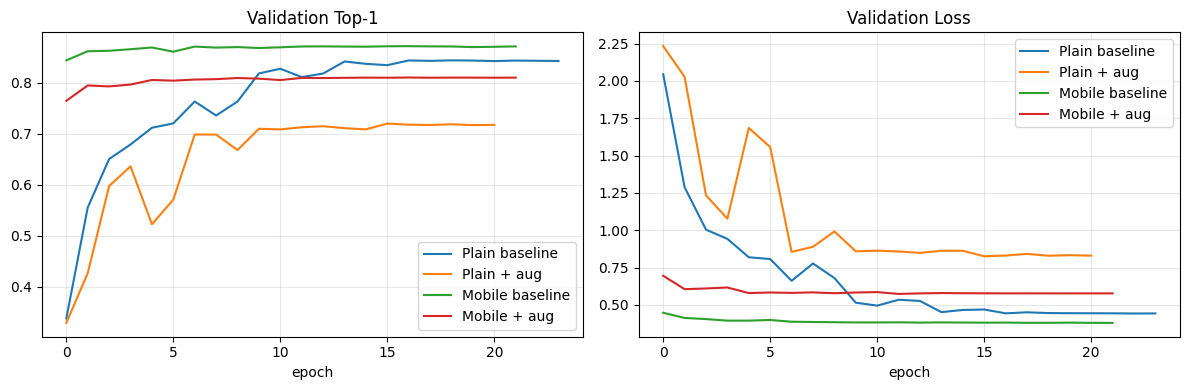

In [21]:
# 8. Data Augmentation 前後對照
plain_aug=build_plain(augment=True)
plain_aug_hist,plain_aug_time=train_model(plain_aug,'plain_aug')
mobile_aug=build_mobilenet(augment=True)
mobile_aug_hist,mobile_aug_time=train_model(mobile_aug,'mobile_aug')

aug_rows=[]
for m,name,secs in [(plain,'Plain baseline',plain_time),(plain_aug,'Plain + augmentation',plain_aug_time),
                    (mobile,'Mobile baseline',mobile_time),(mobile_aug,'Mobile + augmentation',mobile_aug_time)]:
    row,_,_=evaluate_model(m,name,secs); aug_rows.append(row)
aug_comparison=pd.DataFrame(aug_rows)
display(aug_comparison); aug_comparison.to_csv(OUT/'augmentation_comparison.csv',index=False)
plot_history({'Plain baseline':plain_hist,'Plain + aug':plain_aug_hist,
              'Mobile baseline':mobile_hist,'Mobile + aug':mobile_aug_hist},'augmentation_history.png')

### Data Augmentation 結果分析

加入資料擴增後，Plain CNN 測試 Top-1 從 **0.8427 降至 0.7116**，Top-5 從 **0.9931 降至 0.9789**；MobileNetV2 的 Top-1 從 **0.8909 降至 0.8026**，Top-5 從 **0.9965 降至 0.9896**。因此本次設定沒有提升測試表現，Plain CNN 與 MobileNetV2 的 Top-1 分別下降 0.1311 與 0.0883。

訓練曲線顯示 augmentation 版本的 validation Top-1 較低、validation loss 較高；Plain CNN augmentation 版本約停在 0.72，MobileNetV2 augmentation 版本約停在 0.81。這表示水平翻轉、10% 平移、約 ±28.8° 旋轉、10% 縮放與對比變化同時套用，對只有 32×32 的 CIFAR-10 可能過強，使重要輪廓或局部特徵被破壞。另一個限制是 MobileNetV2 兩版本的 fine-tuning 流程不同。

後續可將平移降至 0.05、旋轉降至 0.03、縮放與對比降至 0.05，並讓 baseline 與 augmentation 版本使用相同初始化與完全相同的 fine-tuning 流程，再判斷 augmentation 本身是否改善泛化能力。本作業依實際結果誠實呈現：資料擴增並非一定提高準確率，其強度必須配合影像解析度與訓練策略調整。


## Quiz 3 進階（一）：視覺化兩個 CNN Kernel

以下取 Plain CNN 第一層卷積核。RGB kernel 直接 min-max 正規化後顯示，並另外顯示對測試影像產生的 activation map。Kernel 本身只能支持「可能偏好何種顏色／方向邊緣」的假說；搭配 activation map 才較能判斷其用途。

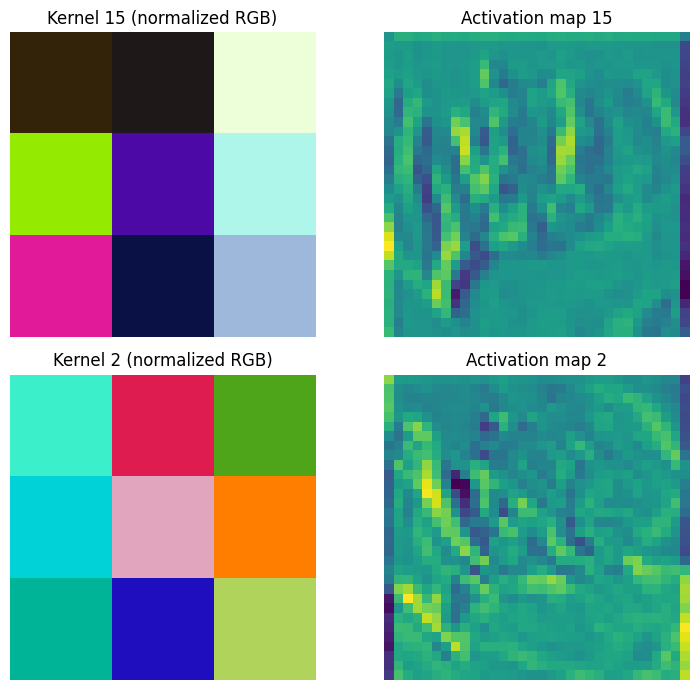

Selected kernel indices: [15  2] | image: 0 | true/pred: cat cat


In [22]:
# 9. 兩個 kernel 與其 activation map
kernel_layer = plain_aug.get_layer('multiscale_3x3')
kernels=kernel_layer.get_weights()[0]  # [3,3,3,num_filters]
kernel_energy=np.std(kernels,axis=(0,1,2))
chosen=np.argsort(kernel_energy)[-2:][::-1]  # 選變化最大的兩個，較具可視性
sample_index=int(np.where(predictions['Plain CNN']==y_test)[0][0])
sample_img=x_test[sample_index:sample_index+1]
activation_model=keras.Model(plain_aug.input,kernel_layer.output)
acts=activation_model.predict(sample_img,verbose=0)[0]

fig,axes=plt.subplots(2,2,figsize=(8,7))
for row,k in enumerate(chosen):
    w=kernels[:,:,:,k]; w=(w-w.min())/(w.max()-w.min()+1e-8)
    axes[row,0].imshow(w); axes[row,0].set_title(f'Kernel {k} (normalized RGB)')
    axes[row,1].imshow(acts[:,:,k],cmap='viridis'); axes[row,1].set_title(f'Activation map {k}')
    axes[row,0].axis('off'); axes[row,1].axis('off')
plt.tight_layout(); plt.savefig(OUT/'two_kernels_and_activations.png',dpi=200); plt.show()
print('Selected kernel indices:',chosen,'| image:',sample_index,
      '| true/pred:',class_names[y_test[sample_index]],class_names[plain_aug.predict(sample_img,verbose=0).argmax()])

### Kernel 與 Activation Map 分析

- **Kernel 15**：權重在 RGB 通道間呈現明顯的正負色彩對比；activation map 在貓的左側輪廓、臉部附近，以及前景藍色區域的交界處反應較強。推測此 kernel 偏向偵測斜向輪廓及前景與背景之間的色彩邊界。
- **Kernel 2**：權重同樣具有強烈色彩差異，activation 在影像左側、貓的外輪廓與下方前景交界較明顯，也對部分細碎紋理產生反應。推測它偏向擷取局部紋理、亮暗變化與物體邊界。
- 第一層 filter 通常學到的是低階顏色、方向、邊緣與紋理，更深層才會把這些訊號組合成物件部件。上述用途是根據 kernel 權重及 activation map 所作的合理推論，不能宣稱單一 kernel 具有唯一且固定的語意。


## Quiz 3 進階（二）：Grad-CAM 解釋模型預測

Grad-CAM 使用目標類別分數對最後卷積特徵圖的梯度作通道權重，產生空間重要度熱圖。紅／黃區域表示對當前預測較有正向貢獻，但不代表因果關係。以下同時挑選正確與錯誤案例，避免只展示成功範例。

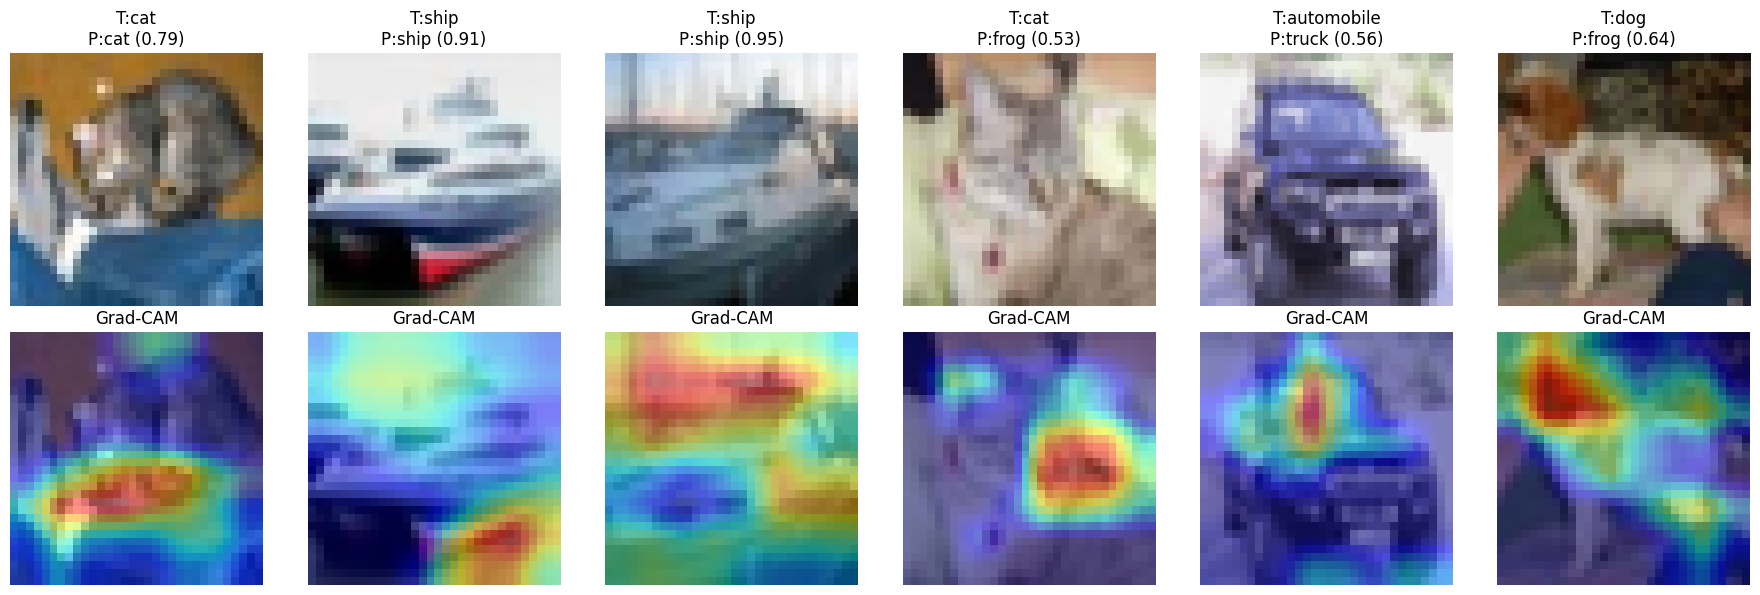

In [23]:
# 10. Grad-CAM（以 Plain CNN 最後一層卷積 conv3_b 為例）
def gradcam(model,img,last_conv='conv3_b',class_index=None):
    grad_model=keras.Model(model.inputs,[model.get_layer(last_conv).output,model.output])
    x=tf.cast(img,tf.float32)
    with tf.GradientTape() as tape:
        conv,preds=grad_model(x,training=False)
        if class_index is None: class_index=tf.argmax(preds[0])
        score=preds[:,class_index]
    grads=tape.gradient(score,conv)
    weights=tf.reduce_mean(grads,axis=(1,2))
    heat=tf.reduce_sum(conv*weights[:,None,None,:],axis=-1)[0]
    heat=tf.maximum(heat,0); heat=heat/(tf.reduce_max(heat)+1e-8)
    return heat.numpy(),int(class_index),preds.numpy()[0]

probs_aug=plain_aug.predict(test_ds,verbose=0); pred_aug=probs_aug.argmax(1)
correct=np.where(pred_aug==y_test)[0][:3]; wrong=np.where(pred_aug!=y_test)[0][:3]
indices=np.concatenate([correct,wrong])
fig,axes=plt.subplots(2,len(indices),figsize=(3*len(indices),6))
for j,i in enumerate(indices):
    heat,p,prob=gradcam(plain_aug,x_test[i:i+1])
    heat=tf.image.resize(heat[...,None],(32,32)).numpy().squeeze()
    axes[0,j].imshow(x_test[i]); axes[0,j].axis('off')
    axes[0,j].set_title(f'T:{class_names[y_test[i]]}\nP:{class_names[p]} ({prob[p]:.2f})')
    axes[1,j].imshow(x_test[i]); axes[1,j].imshow(heat,cmap='jet',alpha=.48,vmin=0,vmax=1)
    axes[1,j].axis('off'); axes[1,j].set_title('Grad-CAM')
plt.tight_layout(); plt.savefig(OUT/'gradcam_examples.png',dpi=200); plt.show()

### Grad-CAM 可解釋性分析

本圖選取三個正確案例與三個錯誤案例。正確案例中，第一張 cat 的熱區主要位於貓下方的身體／前景交界，兩張 ship 則分別關注船身、上方輪廓及周圍高對比區域，表示模型部分使用了與物體形狀相關的證據；但熱區也延伸到水面或背景，因此模型並非只依賴物體主體。

錯誤案例中，cat 被判為 frog（信心 0.53）時，熱區集中於下方身體與背景交界；automobile 被判為 truck（0.56）時，熱區位於車輛中央與車頭，顯示模型確實看見車體，但無法充分區分相近交通工具；dog 被判為 frog（0.64）時，熱區偏向影像左側背景及局部輪廓，可能受到背景色彩與局部紋理干擾。

整體而言，Grad-CAM 顯示模型在部分正確案例會利用物體輪廓，但也可能依賴背景或高對比區域。Grad-CAM 的空間解析度受最後卷積特徵圖大小限制，只能描述特定預測中的敏感區域，不能證明該區域與類別之間具有因果關係。


## 結論

1. 本研究以固定分層切分的 CIFAR-10，比較自行設計的 MultiScale-Pyramid Plain CNN 與 ImageNet 預訓練 MobileNetV2。任務是將一張 32×32 RGB 圖片判斷為 10 種真實事物中最接近的一類。
2. 基準模型中最佳者為 **MobileNetV2**，測試 Top-1／Top-5／Macro-AUC 分別為 **0.8909／0.9965／0.992878**，參數量為 **2,270,794**。Plain CNN 以約七分之一的參數量取得 0.8427 Top-1，顯示自行設計的小型模型仍具有不錯效率。
3. 超參數組合比較中，Plain CNN 最佳 validation Top-1 為 **0.8714**，對應較寬的 `(64,128,256)` filters；MobileNetV2 最佳為 `lr=0.001`、`dropout=0.2`，validation Top-1 為 **0.8734**。由於部分設定同時改變多個參數，結果用於選模，不作單一參數的因果結論。
4. 本次 Data Augmentation 沒有改善準確率：Plain CNN Top-1 從 0.8427 降至 0.7116，MobileNetV2 從 0.8909 降至 0.8026。可能原因是對 32×32 影像施加的擴增過強，以及 MobileNetV2 比較流程中的 fine-tuning 不一致；後續應降低擴增強度並統一訓練流程。
5. Kernel activation 顯示早期層主要偏好色彩對比、輪廓與局部紋理。Grad-CAM 顯示正確案例部分關注物體主體與輪廓，但錯誤案例可能受到背景、高對比區域或相近類別外觀影響。

### 交付檢查

- 已設定 `FULL_RUN=True` 並完成正式執行。
- 所有程式碼儲存格均保留輸出，且沒有 execution error。
- 已填入實際評估數值、超參數結果、augmentation 分析、Kernel 觀察、Grad-CAM 分析與結論。
- Notebook 執行時會在 `cnn_homework_outputs/` 產生 CSV、PNG 與最佳模型檔；本 Notebook 本身已嵌入主要表格與圖像輸出。
